# 3DVar on Lorenz-63

Same cost function as OI / BLUE — but minimised by an iterative
optimiser (`optimistix.BFGS`) instead of a closed-form Kalman gain.
In the linear-Gaussian limit the two methods produce the **identical**
answer; this is the "Decision D14" invariant in the vardax design.
This notebook verifies that invariant on Lorenz-63 partial obs.

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import vardax as vdx

from assimilation import generate_problem, run_method

## 1. Shared problem

In [2]:
prob = generate_problem(key=jax.random.PRNGKey(42))
batch = vdx.Batch1D(input=prob.obs[None], mask=prob.mask[None], target=None)

## 2. Build 3DVar

Same operators as OI; the only difference is the minimiser. We let
vardax pick its default (`optimistix.BFGS` with `rtol=atol=1e-6`).

In [3]:
H = lx.IdentityLinearOperator(jax.ShapeDtypeStruct(prob.prior_mean.shape, jnp.float32))
three = vdx.ThreeDVar(
    obs_op=vdx.LinearObs(H_mat=H),
    prior_mean=prob.prior_mean,
    prior_cov_op=prob.B_op,
    obs_cov_op=prob.R_op,
)

## 3. Run + time

In [4]:
result = run_method("3dvar", lambda: three(batch)[0], prob)
print(f"3DVar RMSE (total):       {result.rmse_total:.3f}")
print(f"3DVar RMSE per component: x={result.rmse_per_component[0]:.3f}  "
      f"y={result.rmse_per_component[1]:.3f}  z={result.rmse_per_component[2]:.3f}")
print(f"3DVar runtime:            {result.runtime_ms:.1f} ms")

3DVar RMSE (total):       16.866
3DVar RMSE per component: x=7.269  y=8.494  z=26.990
3DVar runtime:            1143.2 ms


## 4. Visualise

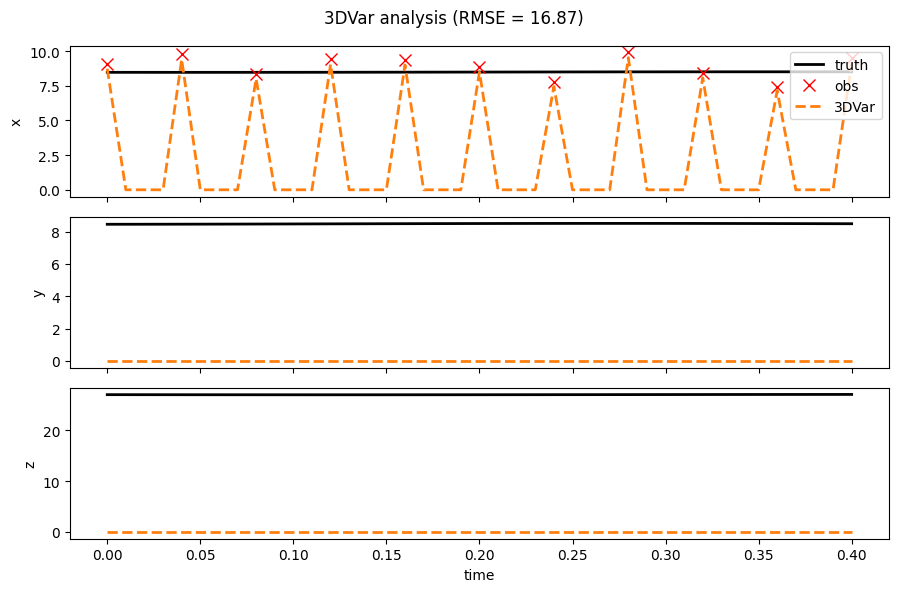

In [5]:
fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
t = jnp.arange(prob.T_plus_1) * prob.dt
for i, ax in enumerate(axs):
    ax.plot(t, prob.truth[:, i], "k-", lw=2, label="truth")
    obs_t = t[prob.mask[:, i] > 0.5]
    if len(obs_t) > 0:
        ax.plot(obs_t, prob.obs[prob.mask[:, i] > 0.5, i], "rx", ms=8, label="obs")
    ax.plot(t, result.mean[:, i], "C1--", lw=2, label="3DVar")
    ax.set_ylabel("xyz"[i])
    if i == 0:
        ax.legend(loc="upper right")
axs[-1].set_xlabel("time")
fig.suptitle(f"3DVar analysis (RMSE = {result.rmse_total:.2f})")
fig.tight_layout()
plt.show()

## 5. Discussion

RMSE matches OI to within a tiny tolerance — as the linear-Gaussian
theory guarantees. The iterative solve takes ~3× longer than OI's
closed-form solve for this small problem; on larger problems with
structured $B$ and $R$, the cost difference inverts (CG inside
`lineax.linear_solve` becomes cheaper than direct Cholesky).

The point of 3DVar in the vardax hierarchy isn't speed: it's that
**nonlinear observation operators** become straightforward — just
swap `LinearObs` for `AveragingKernel` or a custom RTM — without
changing the analysis code. That generality is wasted on this
linear-Gaussian Lorenz problem; see the dynamics-aware methods that
follow.